<a href="https://colab.research.google.com/github/mysticgrud/magshimim/blob/class-22/%D7%A2%D7%95%D7%AA%D7%A7_%D7%A9%D7%9C_%D7%9E%D7%97%D7%91%D7%A8%D7%AA_%D7%9C%D7%99%D7%91%D7%99_%D7%91%D7%9F_%D7%90%D7%9C%D7%99%D7%94%D7%95_%D7%AA%D7%A8%D7%92%D7%95%D7%9C_KNN_%D7%95%D7%9E%D7%A0%D7%99%D7%A4%D7%95%D7%9C%D7%A6%D7%99%D7%95%D7%AA_%D7%91%D7%A9%D7%95%D7%A8%D7%94_%D7%90%D7%97%D7%AA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>

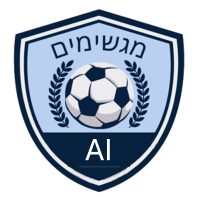


<div dir="rtl">
<font color="Grey">
זכרו ליצור עותק של מחברת זו, לשנות את שמו ולעבוד על העותק האישי שלכם.
<br>
בהצלחה!
</font>
</div>

<div dir="rtl" align="center">

<H1>
<font color='#141C3A'>
<b> חלק א' - נבחרת כדורגל AI
</font>
</H1>
</div>


<div dir=rtl>

בואו נכנס לעולם הספורט המרתק ונגלה כיצד ניתן לחזות ולסווג תכונות של השחקנים במשחק הכדורגל המפורסם FIFA, באמצעות שילוב של K-Nearest Neighbors ו-Pandas. תוכלו להיות חלק מהתהליך המרתק של חיזוי וסיווג שחקני כדורגל, וכל זאת עם עזרת הכלים שלמדנו עד כה.


למי שלא אוהב או מבין בכדורגל- לא לדאוג! התרגיל מעניין וקל להבנה גם למי שאין לו מושג בכדורגל.<br>

<div dir="rtl">
<font color='#Green' size="4">
<b>
 מטרת המודל שלנו היא לבדוק האם ניתן למצוא חוקיות בשקלול הנתונים של השחקנים כדי לדעת מה הרמה המקצועית של כל שחקן ביחס לאחרים.
</font>
<br>


<div dir= rtl>

**סעיף 1**

 בחלק זה נשתמש ב-[קובץ נתונים מכאן](https://colab.research.google.com/drive/1AHhu7PmgSDDgHFFOwMQobndaLes5RSUp?usp=sharing).

טענו את קובץ הנתונים לתוך DataFrame.



In [ ]:
#@title טעינת נתונים
import pandas as pd
import seaborn as sns


players_df = pd.read_csv('https://drive.google.com/uc?id=1e30XlD5RMSe6TqtJoSB465_ib3L-Silc')
players_df

,Name,Rating,Position,Country,Speed,Shooting,Passing,Dribbling,Defending,Physicality,Link
0,Mohamed Salah,99,CAM,Egypt,99,99,96,99,54,88,https://wefut.com/player/22/23557/mohamed-salah
1,Ousmane Dembélé,99,RW,France,99,96,94,99,49,79,https://wefut.com/player/22/22456/ousmane-dembele
2,Raphaël Varane,99,CB,France,96,61,80,83,99,98,https://wefut.com/player/22/22450/raphael-varane
3,Cristiano Ronaldo,99,LW,Portugal,99,99,90,97,50,92,https://wefut.com/player/22/22188/cristiano-ro...
4,Lionel Messi,99,CF,Argentina,95,98,99,99,42,78,https://wefut.com/player/22/22165/lionel-messi
...,...,...,...,...,...,...,...,...,...,...,...
20678,Patrick Ferry,47,ST,Northern Ireland,49,48,38,43,18,37,https://wefut.com/player/22/17124/patrick-ferry
20679,Fang Xinfeng,47,CDM,China PR,54,31,43,44,43,52,https://wefut.com/player/22/17123/fang-xinfeng
20680,Wang Shilong,47,CB,China PR,61,23,27,33,52,46,https://wefut.com/player/22/17122/wang-shilong
20681,Darren Collins,47,ST,Republic of Ireland,68,48,43,51,31,35,https://wefut.com/player/22/17121/darren-collins


<div dir=rtl>

חקרו את העמודות השונות במסד הנתונים (סוג, ערכים חסרים)

In [ ]:
# הקוד שלכם כאן
players_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20683 entries, 0 to 20682
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         20683 non-null  object
 1   Rating       20683 non-null  int64 
 2   Position     20683 non-null  object
 3   Country      20682 non-null  object
 4   Speed        20683 non-null  int64 
 5   Shooting     20683 non-null  int64 
 6   Passing      20683 non-null  int64 
 7   Dribbling    20683 non-null  int64 
 8   Defending    20683 non-null  int64 
 9   Physicality  20683 non-null  int64 
 10  Link         20683 non-null  object
dtypes: int64(7), object(4)
memory usage: 1.7+ MB


<div dir="rtl" align="right">
<font color='White' size="5">
<b>
הכרה הנתונים
</b>


<div dir= rtl>

ברכות! אתם נבחרתם להיות המאמנים של קבוצת כדורגל גדולה באירופה וקיבלתם משימה ראשונה מהבעלים של המועדון לבנות את קבוצת החלומות!

<div dir= rtl>

**הסבר על הפיצ'רים:**

**שם (Name):** שם השחקן

**דירוג (Rating):** הדירוג הכולל של השחקן

**מיקום (Position):** מיקום השחקן על המגרש

**מדינה (Country):** המדינה בה השחקן נולד

**מהירות/בעיטה/מסירה/כדרור/הגנה/פיזיות (Speed/Shooting/Passing/Dribbling/Defending/Physicality):** דירוג מ1 עד 99 של היכולת של השחקן בתחום

<div dir="rtl" align="right">
<br>
<b>

*   תוכלו לקרוא [כאן](https://fifauteam.com/fifa-21-attributes-guide/) על המדדים וממה בנוי כל מדד מורכב


<div dir= rtl>

**סעיף 2**

כפי שאנחנו יודעים ומכירים, לפני שמתחילים להתעסק עם הנתונים צריך להבין אותם.

הדפיסו את סוגי ה-Poisition השונים הקיימים בDataframe.


In [ ]:
# הקוד שלכם כאן
print(players_df['Position'].unique())

['CAM' 'RW' 'CB' 'LW' 'CF' 'ST' 'LM' 'CM' 'RM' 'RB' 'CDM' 'RF' 'LB' 'RWB'
 'LF' 'LWB']


<div dir= rtl>

**העשרת ידע:**

בתמונה הבאה ניתן לראות את שמות ה-Positions בהתאם למיקום שלהם במגרש.

המיקומים האחוריים (LB/CB/RB/GK) הם הגנתיים.

המיקומים הקדמיים (ST/CF/LF/RF)  הם התקפיים.

כל השאר הם אמצע.

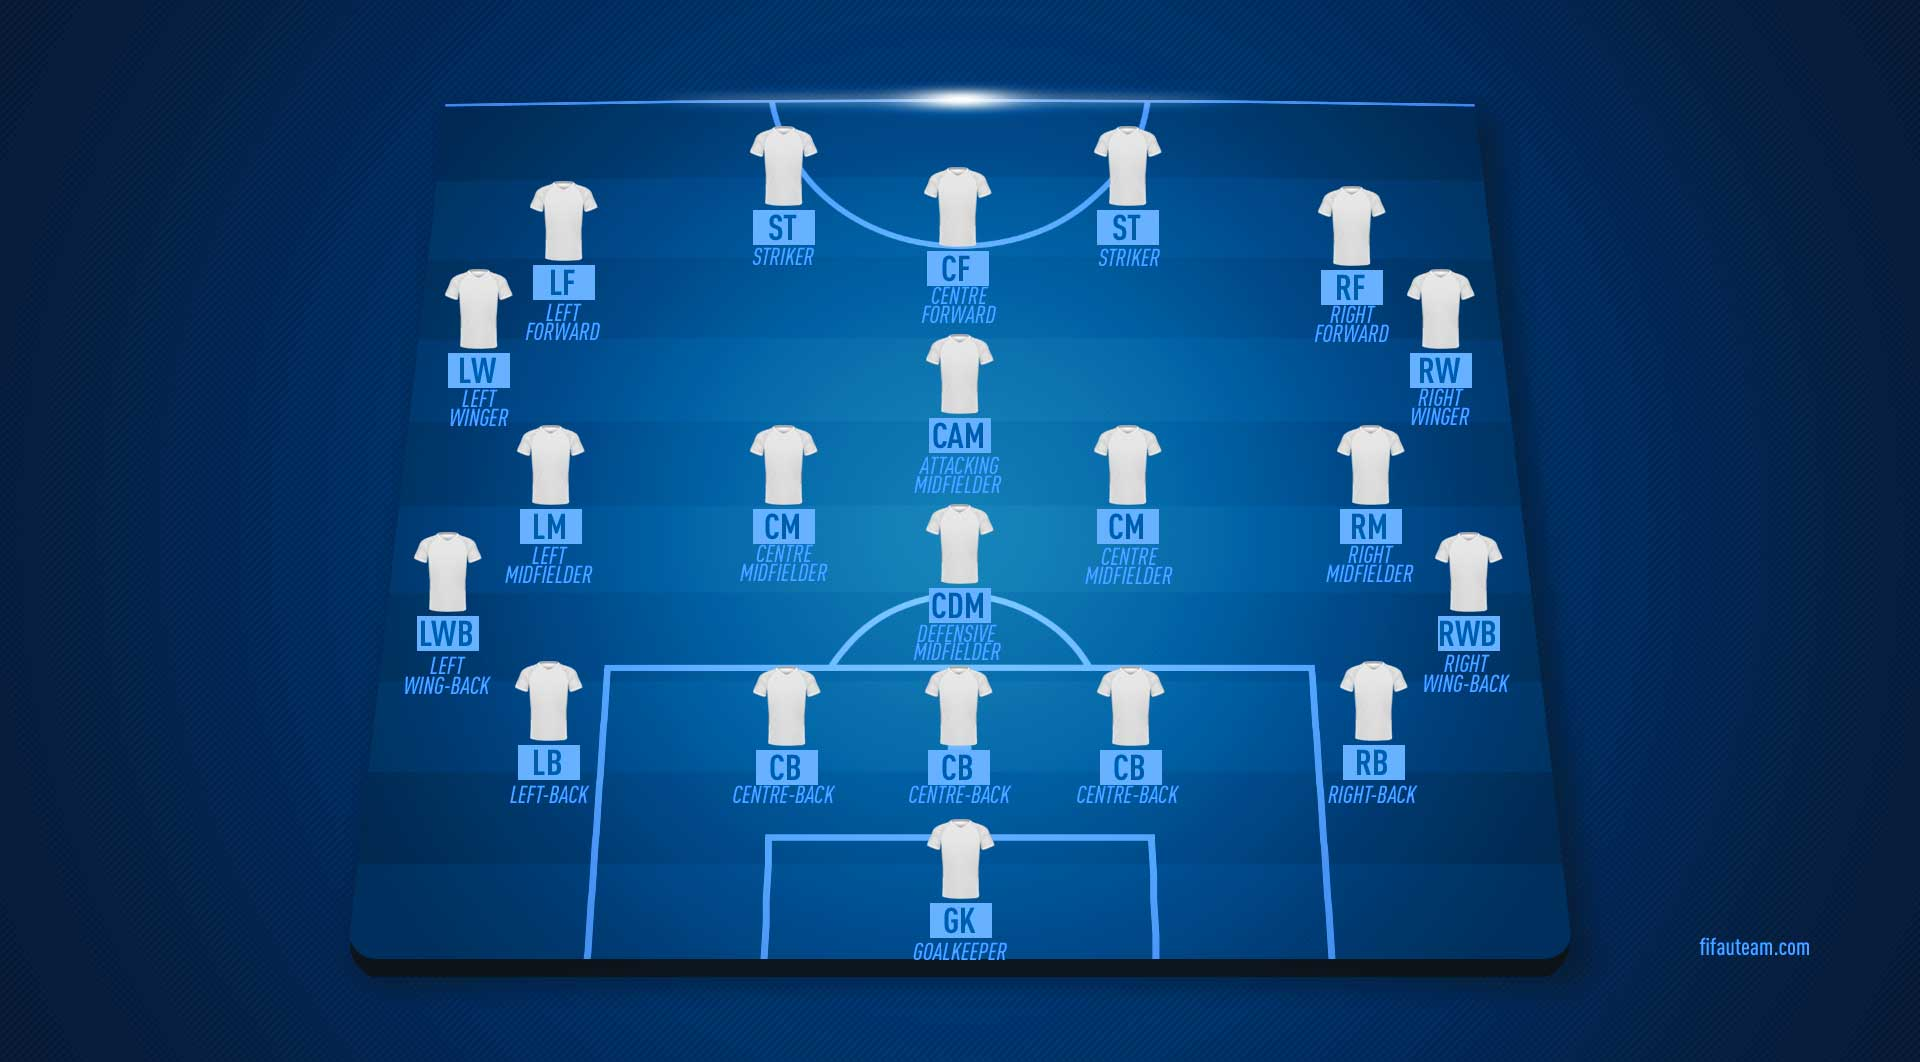

<div dir= rtl>

חקרו את העמדות האחוריות של השחקנים (RB,LB,CB,GK). <br>
מה מציינת כל אות והאם התכונות שבמסד הנתונים תואמות את התפקיד של שחקנים אלו?<br>
תוכלו להרחיב על העמדות בקישור [הבא](https://olympics.com/en/news/how-many-players-in-football-positions).


--------------------------------------------------------------------------------
<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
</font>
<br>

**תשובה:**
RW: Right Winger
CB: Center Back (or Central Defender)
LW: Left Winger
CF: Center Forward (or Striker)
ST: Striker (or Center Forward)
LM: Left Midfielder
CM: Central Midfielder
RM: Right Midfielder
RB: Right Back
CDM: Central Defensive Midfielder
RF: Right Forward
LB: Left Back
RWB: Right Wing Back
LF: Left Forward
LWB: Left Wing Back

--------------------------------------------------------------------------------


<div dir= rtl>

**סעיף 3**

ציירו גרף עמודות של ה-Positions של השחקנים (ציר x- מיקום במגרש, ציר y- כמות השחקנים במיקום זה)

<Axes: xlabel='Position', ylabel='count'>

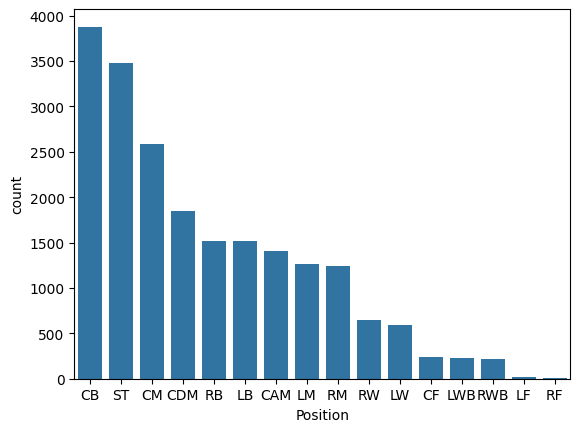

In [ ]:
# הקוד שלכם כאן
import seaborn as sns
sns.barplot(players_df['Position'].value_counts())


<div dir= rtl>

**סעיף 4**

מה ניתן להסיק מהגרף?

האם זה יכול להשפיע על המודל אם נאמן לפי המידע הזה?



--------------------------------------------------------------------------------
<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
כן בגלל שיש כמויות שונות של כל שחקן בכל מיקום כך שלא ניתן להסיק מסקנות באופן כללי נגיד לגבי RF כי יש מעט מאוד כאלה
</font>
<br>

**תשובה:**


--------------------------------------------------------------------------------

<div dir= rtl>

**סעיף 5**

נרצה לבדוק אלו מדינות מובילות בדירוג כדי לקבל חוות דעת על רמת הליגות המקומיות.<br>
הדפיסו את המדינות מסודרות לפי הממוצע של דירוג השחקנים שלהם, האם אתם מופתעים מהתוצאות? נסו להסביר אותן.

In [ ]:
# הקוד שלכם כאן
ndf = players_df.groupby('Country')['Rating'].mean().reset_index()
ndf = ndf.sort_values(by='Rating', ascending=True)

print(ndf)

                  Country     Rating
107                 Niger  52.000000
67              Hong Kong  53.000000
70                  India  54.412698
131           South Sudan  54.500000
92               Malaysia  57.000000
..                    ...        ...
74                  Italy  76.091295
118              Portugal  76.174641
26   Central African Rep.  76.666667
7                 Armenia  78.181818
42                  Egypt  81.480000

[157 rows x 2 columns]



--------------------------------------------------------------------------------
<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
</font>
<br>

**תשובה:**
כן כיוון שלא ציפיתי שניגריה תיהיה הכי נמוכה כי אני חשבתי שנגרים טובים בכדורגל

--------------------------------------------------------------------------------

<div dir="rtl" align="right">
<font color='White' size="5">
<b>
הנדסת פיצ'רים
</b>


<div dir= rtl>

**סעיף 6**

אנו רוצים לחלק את השחקנים לשלוש מחלקות: מצויין, בינוני וגרוע.<Br>
בחרו פיצ'ר שיכול לעזור לכם לסווג את השחקנים למחלקות וחקרו עליו ב-Google והסבירו מדוע בחרתם דווקא בו.



--------------------------------------------------------------------------------
<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
rating כיוון שזה אומר על כל שחקן באופן כללי מה רמתו
</font>
<br>

**תשובה:**

--------------------------------------------------------------------------------


<div dir= rtl>

**סעיף 7**

על סמך הפיצ'ר שבחרתם, כתבו <b> פונקציה </b> המחלקת את השחקנים למחלקות מצויין, בינוני וגרוע באיזו חלוקה שתרצו (ממוצע, שכיח, חציון וכו').<br>
הפונקציה מקבלת את ערך הפיצ'ר שבחרתם ומחזירה את המחלקה של השחקן (מצויין, בינוני או גרוע).<br>
שימו לב שאנו רוצים שהמחלקות יהיו גדולות מספיק ושלא תתקבל מחלקה קטנה בפער משמעותי מהאחרות.


In [ ]:
# הקוד שלכם כאן
def players_ratings(players_df):
    ratings = []
    for rating in players_df['Rating']:
        if rating <= 60:
            ratings.append('Low Rating')
        elif 61 <= rating <= 79:
            ratings.append('Medium Rating')
        elif 80 <= rating <= 100:
            ratings.append('High Rating')
    return ratings

ratings = players_ratings(players_df)
print(ratings)

['High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rating', 'High Rat

<div dir= rtl>

בדקו את גודל המחלקות:

In [ ]:
# הקוד שלכם כאן
print(sum(rating == 'High Rating' for rating in ratings))
print(sum(rating == 'Medium Rating' for rating in ratings))
print(sum(rating == 'Low Rating' for rating in ratings))

2660
14752
3271


<div dir= rtl>
<b>

מדוע חשוב לנו שלא תהיה מחלקה קטנה בפער משמעותי משאר המחלקות?



--------------------------------------------------------------------------------
<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
כי זה אומר שהאדאטאסט לא מאוזן ואי אפשר לבנות אליו מודל שיעבוד באון כללי
</font>
<br>


**תשובה:**

--------------------------------------------------------------------------------


<div dir= rtl>

**סעיף 8**

הדפיסו את הדירוג (Rating) הממוצע של השחקנים מכל סוג (מצויין, בינוני וגרוע)

In [ ]:
# הקוד שלכם כאן
#כאן אני יעשה את מה שעשיתי לפני כן אבל במקום להכניס את זה לליסט לעשות את זה בצורה נורמאלית שאני יוכל לעבוד איתה
def players_ratings(players_df):
    ratings = []
    for rating in players_df['Rating']:
        if rating <= 60:
            ratings.append('Low Rating')
        elif 61 <= rating <= 79:
            ratings.append('Medium Rating')
        elif 80 <= rating <= 100:
            ratings.append('High Rating')
    players_df['Rating Category'] = ratings
    return players_df

players_df = players_ratings(players_df)

print(players_df[players_df['Rating Category'] == 'High Rating']['Rating'].mean())
print(players_df[players_df['Rating Category'] == 'Medium Rating']['Rating'].mean())
print(players_df[players_df['Rating Category'] == 'Low Rating']['Rating'].mean())


87.03308270676692
68.12859273318873
56.84897584836442


<div dir="rtl" align="right">
<font color='White' size="5">
<b>
המשך הכרת הנתונים
</b>


<div dir= rtl>

**סעיף 9**

 מאיזה מדינה מגיעים הכי הרבה שחקנים מסוג מצויינים?

In [ ]:
# הקוד שלכם כאן
players_df[players_df['Rating Category'] == 'High Rating']['Country'].value_counts()

Country
France                  322
England                 265
Spain                   262
Brazil                  222
Germany                 182
                       ... 
Russia                    1
Central African Rep.      1
New Zealand               1
Peru                      1
China PR                  1
Name: count, Length: 77, dtype: int64

<div dir= rtl>

**סעיף 10**

לשחקנים יש הרבה נתונים מספריים שמאפיינים אותם. בואו נבדוק אם יש קשר בין הנתונים.

בדקו את הקורלציה בין כל נתוני השחקנים

איפה יצא לכם קורלציה הכי חזקה?


 **בונוס**: קראו על פונקציה בשם [heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html) ונסו להציג את הקשר באופן ויזואלי. (כאשר פרמטר cmap='crest')


--------------------------------------------------------------------------------
<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
</font>
<br>


**תשובה:**
בין passing לdribbling

--------------------------------------------------------------------------------


In [ ]:
# הקוד שלכם כאן
coor = players_df[['Speed', 'Shooting', 'Passing', 'Dribbling', 'Defending', 'Physicality']].corr()
print(coor)

                Speed  Shooting   Passing  Dribbling  Defending  Physicality
Speed        1.000000  0.482583  0.461245   0.633520  -0.152138     0.057717
Shooting     0.482583  1.000000  0.747057   0.830090  -0.261093     0.211182
Passing      0.461245  0.747057  1.000000   0.898810   0.248311     0.354577
Dribbling    0.633520  0.830090  0.898810   1.000000   0.012311     0.254437
Defending   -0.152138 -0.261093  0.248311   0.012311   1.000000     0.550314
Physicality  0.057717  0.211182  0.354577   0.254437   0.550314     1.000000


<Axes: >

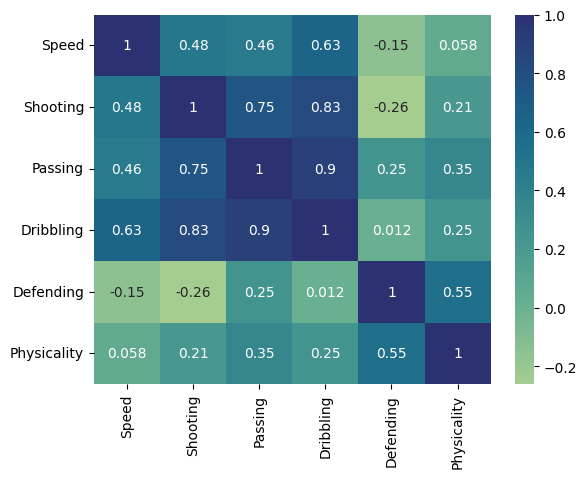

In [ ]:
# הקוד שלכם כאן
sns.heatmap(coor, annot=True, cmap='crest')

<div dir= rtl>

מה לדעתכם מייצג ריבוע כהה במפת החום? האם קשר חזק/חלש או משהו אחר לגמרי?


--------------------------------------------------------------------------------
<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
</font>
<br>


**תשובה:**

ככל שהריבוע בהיר יותר כל הקוראלציה נמוכה יותר כככל שהיא ככה יותר כך היא גבוהה יותר
--------------------------------------------------------------------------------


<div dir= "rtl">

**סעיף 11**


1.   צרו גרף פיזור (Scatter Plot) עם שני הפיצ'רים בעלי הקורלציה הגבוהה ביותר וצבעו את הנקודות בגרף לפי רמת השחקן (המחלקות השונות)
2.   בדקו האם השחקנים בעלי הרמה הגבוהה ביותר הם גם בעלי הדירוג הגבוה בנתונים שמצאתם וציינו איזו מחלקה של רמת שחקן היא בעלת הציונים הגבוהים ביותר? (ענו למטה)






<Axes: xlabel='Passing', ylabel='Dribbling'>

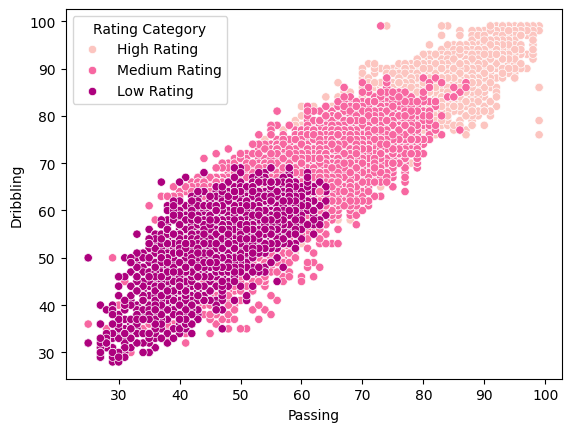

In [ ]:
# הקוד שלכם כאן
sns.scatterplot(data=players_df, x='Passing', y='Dribbling', hue='Rating Category', palette='RdPu')


--------------------------------------------------------------------------------
<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
</font>
<br>


**תשובה:**
כן, הרמה הכי גבוהה (HIGH RATING)

--------------------------------------------------------------------------------


<div dir= "rtl">

**סעיף 12**

הריצו את קטע הקוד הבא הדוגם 5000 תצפיות ומדפיס אותן על גבי גרף פיזור תלת מימדי עם שלושה פיצ'רים שבחרנו: Passing, Dribbling , Speed.
התבוננו בגרף והסבירו האם לדעתכם מודל ה-KNN יעבוד טוב עם שלושת הפיצ'רים האלו?



--------------------------------------------------------------------------------
<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
</font>
<br>


**תשובה:**


--------------------------------------------------------------------------------


In [ ]:
# @title הרץ אותי
import plotly.express as px

fig = px.scatter_3d(players_df[['Passing','Dribbling','Speed','Rating Category']].sample(5000), x='Passing', y='Dribbling', z='Speed',
              color='Rating Category',color_discrete_map={'High Rating': 'pink', 'Medium Rating': 'magenta', 'Low Rating': 'cyan'},
              )
fig.update_traces(marker={'size': 5})

fig.show()

<div dir= "rtl">

**סעיף 13**

האם לדעתכם מודל עם N פיצ'רים יעבוד טוב יותר משניים/שלושה פיצ'רים?<br>
מה הבעיה שתהיה לנו עם N פיצ'רים?



--------------------------------------------------------------------------------
<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
</font>
<br>

**תשובה:**
אני לא בטוחה כיוון שזה מאוד תלוי נתונים, יש נתונים בהם שימוש בכמה פיצ'רים יכולה להשפיע לטובה על הדיוק ויש מקרים בהם הנתונים לא מסודרים ככמו שצריך בחלק מהעמודות אזי זה לא היה עוזר.

--------------------------------------------------------------------------------


<div dir="rtl" align="center">

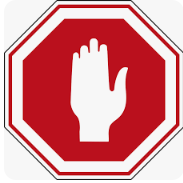
<br><br>

<font color="red" size="8"><b>
עצרו כאן! חכו להוראות המדריך ולהמשך המצגת
</b></font><br><br><br>

<div dir="rtl" align="center">
<b><font color="Grey">

<H1>
<font color='#141C3A'>
<b> חלק ב' - מניפולציות בשורה אחת
</font>
</H1>
</div>


<div dir= "rtl">

בחלק זה תצטרכו לתקן שורות קוד שיש בהן שגיאה ובנוסף לפתור שאלות תכנות שונות על ידי תכנות בשורה אחת בשיטות שראינו במחברת ההדגמה (lambda, map , filter).<br>
נמשיך לעבוד עם <b>המסד נתונים של שחקנים הכדורגל שטענתם בחלק א' של המחברת.</b><br>

<div dir="rtl" align="right">
<font color='red' size="4">
 <b>
לאחר כל סעיף שעניתם, הציגו פלט המראה שהפונקציה שכתבתם עובדת.
</b>




<div dir="rtl" align="right">
<font color='white' size="5">
 <b>
במידה ואתם צריכים רענון לפונקציות, לחצו על הלינק מטה כדי להיכנס למחברת רענון

[מעבר למחברת רענון](https://colab.research.google.com/drive/1k6tbTl_TudGcs_n0wpy7_y6s70FtcDmA?usp=sharing)


<div dir= "rtl">

**סעיף 1**

הקוד הבא לא רץ הסבירו מדוע ותקנו אותו.


In [ ]:
capitalized_names = list(map(lambda x: x['Name'].capitalize(), players_df.to_dict('records')))
print(capitalized_names)

['Mohamed salah', 'Ousmane dembélé', 'Raphaël varane', 'Cristiano ronaldo', 'Lionel messi', 'Robert lewandowski', 'Pelé', 'Neymar jr', 'Wissam ben yedder', 'Abedi pelé', 'David ginola', "N'golo kanté", 'Franck ribéry', 'Alexis sánchez', 'Kalidou koulibaly', 'Paulo dybala', 'Sadio mané', 'Erling haaland', 'Diego maradona', 'Julián álvarez', 'Ivan perišić', 'Jules koundé', 'Christian eriksen', 'Gareth bale', 'Pelé', 'Mohamed salah', 'Lionel messi', 'Robert lewandowski', 'Allan saint-maximin', 'Iván córdoba', 'Diego milito', 'Antonio di natale', 'Diego milito', 'Ole gunnar solskjær', 'Ole gunnar solskjær', 'Marcus rashford', 'Marcelo', 'Heung min son', 'Richarlison', 'Raheem sterling', 'Antonio rüdiger', 'Ryan gravenberch', 'Zinedine zidane', 'Ronaldo', 'Georginio wijnaldum', 'Paul pogba', 'Wissam ben yedder', 'Diego maradona', 'Rafael leão', 'Lionel messi', 'Karim benzema', 'Luka modrić', 'Robert lewandowski', 'Joshua kimmich', 'Cristiano ronaldo', 'Mohamed salah', 'Cristiano ronaldo', '



<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
</font>
<br>


**תשובה:**
פונקצית מאפ לא יכולה לעבוד בדבר כזה והיא צרכה לעבוד על דיקט וגם השם של הנתונים שאנחנו מככניסים לא היה נון
--------------------------------------------------------------------------------


<div dir= "rtl">

**סעיף 2**

הקוד הבא לא רץ הסבירו מדוע ותקנו אותו.


In [ ]:
def filterByCountry(country, df):
    return df[df['Country'] == country]


result = filterByCountry("Spain", players_df)
print(result)

                Name  Rating Position Country  Speed  Shooting  Passing  \
67      Sergio Ramos      96       ST   Spain     97        95       90   
87     Ferran Torres      96       RW   Spain     99        92       96   
97             Pedri      96       CM   Spain     93        87       95   
120     Adama Traoré      95       CF   Spain     99        94       91   
146       Carles Gil      95      CAM   Spain     88        88       98   
...              ...     ...      ...     ...    ...       ...      ...   
18897   Miguel Muñoz      58       CB   Spain     63        31       48   
18970      Diego Bri      58       LW   Spain     60        55       57   
19328   Nacho Pastor      57       CB   Spain     63        33       33   
19398      Iker Pozo      57      CDM   Spain     66        44       56   
19594     Dani Vidal      56       CM   Spain     61        45       59   

       Dribbling  Defending  Physicality  \
67            93         90           91   
87         



<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
</font>
<br>

**תשובה:**

השם של הפונקציה היה לא נכון
--------------------------------------------------------------------------------

</b></div>


<div dir= "rtl">

**סעיף 3**

הקוד הבא לא רץ הסבירו מדוע ותקנו אותו.


In [ ]:
for i in range(len(players_df)-1,len(players_df)):
    print(players_df.iloc[i]['Rating'])

62




<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
</font>
<br>

**תשובה:**

צריך היה להשתמש בפונקציץ ILOC כי צריך אותה כדי לגשת למיקומים של דברים בתוך דאטאסט, שלא כמו בליסט שאפשר פשוט להוסיף []
--------------------------------------------------------------------------------

<div dir= "rtl">

**סעיף 4**

הקוד הבא לא רץ הסבירו מדוע ותקנו אותו.

In [ ]:
result = players_df[players_df['Rating'] >= 90]
print(result)

                  Name  Rating Position    Country  Speed  Shooting  Passing  \
0        Mohamed Salah      99      CAM      Egypt     99        99       96   
1      Ousmane Dembélé      99       RW     France     99        96       94   
2       Raphaël Varane      99       CB     France     96        61       80   
3    Cristiano Ronaldo      99       LW   Portugal     99        99       90   
4         Lionel Messi      99       CF  Argentina     95        98       99   
..                 ...     ...      ...        ...    ...       ...      ...   
818      Karim Benzema      90       CF     France     77        87       83   
819     Joshua Kimmich      90      CDM    Germany     72        75       87   
820      Mohamed Salah      90       RW      Egypt     91        89       82   
821       N'Golo Kanté      90      CDM     France     78        66       75   
822         Harry Kane      90       ST    England     70        91       83   

     Dribbling  Defending  Physicality 



<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
</font>
<br>

**תשובה:**
הסימן => לא קיים בפייטון

--------------------------------------------------------------------------------

<div dir= "rtl">

**סעיף 5**

הקוד הבא לא רץ הסבירו מדוע ותקנו אותו.


In [ ]:
country_counts = {}
for index, player in players_df.iterrows():
    country = player['Country']
    if country not in country_counts:
      country_counts[country] = 1
    else:
      country_counts[country] += 1

print(country_counts)

{'Egypt': 25, 'France': 1272, 'Portugal': 418, 'Argentina': 1107, 'Poland': 396, 'Brazil': 688, 'Ghana': 140, 'Chile': 131, 'Senegal': 156, 'Norway': 385, 'Croatia': 193, 'Denmark': 353, 'Wales': 171, 'Colombia': 318, 'Italy': 471, 'England': 2070, 'Korea Republic': 328, 'Germany': 1403, 'Netherlands': 564, 'Spain': 1240, 'Canada': 85, 'Belgium': 378, 'Uruguay': 278, 'Serbia': 147, 'DR Congo': 65, 'Algeria': 62, 'Gabon': 18, 'Hungary': 42, 'Switzerland': 206, 'United States': 416, 'Sweden': 407, 'New Zealand': 33, 'Mexico': 359, 'Scotland': 333, 'Australia': 261, 'Northern Ireland': 84, 'Slovakia': 59, 'Austria': 344, 'Ecuador': 147, 'Mali': 74, 'Ivory Coast': 164, 'Bulgaria': 28, 'Cameroon': 85, 'Turkey': 288, 'Bosnia Herzegovina': 74, 'Morocco': 121, 'Republic of Ireland': 427, 'Iran': 21, 'Ukraine': 75, 'Czech Republic': 114, 'Romania': 355, 'Nigeria': 179, 'Japan': 571, 'Finland': 56, 'Armenia': 11, 'Peru': 102, 'Venezuela': 121, 'Jamaica': 46, 'Slovenia': 59, 'Comoros': 14, 'Saudi



<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
</font>
<br>

**תשובה:**
אין אפשרות למה שיקרה אם אין מדינה

--------------------------------------------------------------------------------

<div dir= "rtl">

**סעיף 6**

הקוד הבא לא רץ הסבירו מדוע ותקנו אותו.


In [ ]:
good_players = players_df[players_df['Rating Category'] == 'Medium Rating']
average_good_rating = good_players['Rating'].mean()
print(average_good_rating)

68.12859273318873



<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
</font>
<br>

**תשובה:**
שמות הקולומים שיש שם לא מתרימים למה שיש לי בדאטאסט + אי אםשר להפעיל את מתודת הממוצע על אותיות
--------------------------------------------------------------------------------

<div dir= "rtl">

**סעיף 7**

הקוד הבא לא רץ הסבירו מדוע ותקנו אותו.


In [ ]:
players_df['Speed'] = players_df['Speed'].astype(str) + ' km/h'


<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
</font>
<br>

**תשובה:**
הסוג של העמודה לא היה סטרינג ובגלל זה אי אפשר להוסיף לזה את היחידות של קילומטר לשעה כמו שהיו עושים את סטרינג
--------------------------------------------------------------------------------

<div dir= "rtl">

**סעיף 8**

כתבו פונקציה המקבלת דירוג ומחזירה DF המכיל רק את השחקנים שמעל רף הדירוג.

In [ ]:
#השלימו כאן קטע קוד
def func(rating):
  df[df['Rating']> rating]

----------------------------------------------------------

<div dir= "rtl">

**סעיף 9**

כתבו פונקציה המקבלת DF ומחזירה את כל השמות של השחקנים באותיות גדולות.

In [ ]:
#השלימו כאן קטע קוד
def func1(df):
  return df['Name'].str.capitalize()

------------------------------------------------------

<div dir= "rtl">

**סעיף 10**

כתבו פונקציה המקבלת DF ומדינה ומחזירה את ה-DF ממופה לפי המדינה.

In [ ]:
#השלימו כאן קטע קוד
def func2(df1, country):
  return df1[df1['Country']==country]

------------------------------------------------------

<div dir= "rtl">

**סעיף 11**

כתבו פונקציה המקבלת DF ואות, הפונקציה תחזיר את השחקנים שיש להם את האות ב-Position שלהם.

In [ ]:
#השלימו כאן קטע קוד
def func3(df2, letter):
  result = []
  for row in df2:
    if letter.lower() in row['Position'].lower():
      result.append(row['Name'])
  return result

------------------------------------------------------

<div dir= "rtl">

**סעיף 12**

בארגון פיפא הציעו לשנות את שיטת הדירוג שיהיה ממוצע של המדדים Shooting,Passing ו- Dribbling בלבד.<br>
כתבו פונקציה המשנה את הדירוג ב-DF בהתאם (עשו שימוש ב-map). <br>
<b>
שימו לב לבצע copy ל-DataFrame אחרת תדרסו את הנתונים האמיתיים.

In [ ]:
#השלימו כאן קטע קוד
def func4(df):
  df_copy = df.copy()
  for row in df_copy:
    avg = (row['Shooting'] + row['Passing'] + row['Dribbling']) / 3
    df_copy['Rating'][row] = avg
    df_copy = df_copy.sort_values(by='Average', ascending=False)

    return df_copy


------------------------------------------------------

<div dir= "rtl">

**סעיף 13**

פיפא גילתה שהיה טעות בחישוב הדירוג ולכן הוחלט להוריד 2 נקודות דירוג לכל השחקנים.
כתבו פונקציה המעדכנת את דירוג השחקנים. <br>
<b>
שימו לב לבצע copy ל-DataFrame אחרת תדרסו את הנתונים האמיתיים.


In [ ]:
#השלימו כאן קטע קוד
def func5(df):
  df['Rating'] = df['Rating']-2

------------------------------------------------------

<div dir= "rtl">

**סעיף 14**

בהמשך לסעיף הקודם, פיפא גילו שהטעות היא רק אצל שחקנים מצרפת, כלומר עליכם להוריד 2 נקודות רק לשחקנים הצרפתיים (אין צורך להחזיר לשאר את השתי נקודות שהורדו בסעיף הקודם) <br>
<b>
שימו לב לבצע copy ל-DataFrame אחרת תדרסו את הנתונים האמיתיים.


In [ ]:
#השלימו כאן קטע קוד
def func6(df):
  for index, player in df.iterrows():
    if player['Country'] == 'France':
      df.loc[index, 'Rating'] -= 2


------------------------------------------------------

<div dir="rtl" align="center">
<b><font color="Grey">

<H1>
<font color='#141C3A'>
<b> חלק ג' - בניית מודל KNN
</font>
</H1>
</div>


<div dir=rtl>

בחלק זה תממשו בעצמכם מודל KNN.<br>
אנו נעבוד על מסד הנתונים של שחקני הכדורגל שאתם כבר מכירים והפעם <b>ננסה לחזות את העמדה של השחקן (התקפה או הגנה).</b><br>
קודם כל, נטען ספריות ואת מסד הנתונים שוב:

In [ ]:
#@title טעינת נתונים
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

players_df = pd.read_csv('https://drive.google.com/uc?id=1e30XlD5RMSe6TqtJoSB465_ib3L-Silc')
players_df

,Name,Rating,Position,Country,Speed,Shooting,Passing,Dribbling,Defending,Physicality,Link
0,Mohamed Salah,99,CAM,Egypt,99,99,96,99,54,88,https://wefut.com/player/22/23557/mohamed-salah
1,Ousmane Dembélé,99,RW,France,99,96,94,99,49,79,https://wefut.com/player/22/22456/ousmane-dembele
2,Raphaël Varane,99,CB,France,96,61,80,83,99,98,https://wefut.com/player/22/22450/raphael-varane
3,Cristiano Ronaldo,99,LW,Portugal,99,99,90,97,50,92,https://wefut.com/player/22/22188/cristiano-ro...
4,Lionel Messi,99,CF,Argentina,95,98,99,99,42,78,https://wefut.com/player/22/22165/lionel-messi
...,...,...,...,...,...,...,...,...,...,...,...
20678,Patrick Ferry,47,ST,Northern Ireland,49,48,38,43,18,37,https://wefut.com/player/22/17124/patrick-ferry
20679,Fang Xinfeng,47,CDM,China PR,54,31,43,44,43,52,https://wefut.com/player/22/17123/fang-xinfeng
20680,Wang Shilong,47,CB,China PR,61,23,27,33,52,46,https://wefut.com/player/22/17122/wang-shilong
20681,Darren Collins,47,ST,Republic of Ireland,68,48,43,51,31,35,https://wefut.com/player/22/17121/darren-collins


<div dir= rtl>

מפו את ה-Dataframe שלנו כך שיכיל רק שחקנים שהמיקום שלהם הוא [ST](https://soccerwhizz.com/st-meaning-in-soccer/) או [CB](https://soccerwhizz.com/cb-meaning-in-soccer/) (כלומר שיהיו לנו רק תוקפים Striker או מגנים Center Back)

In [ ]:
#השלימו כאן קטע קוד
df = players_df[(players_df['Position'] == 'ST') | (players_df['Position'] == 'CB')]
df

,Name,Rating,Position,Country,Speed,Shooting,Passing,Dribbling,Defending,Physicality,Link
2,Raphaël Varane,99,CB,France,96,61,80,83,99,98,https://wefut.com/player/22/22450/raphael-varane
5,Robert Lewandowski,99,ST,Poland,97,99,90,98,52,98,https://wefut.com/player/22/23562/robert-lewan...
8,Wissam Ben Yedder,98,ST,France,99,99,93,99,55,85,https://wefut.com/player/22/22451/wissam-ben-y...
10,David Ginola,98,ST,France,98,96,95,97,63,92,https://wefut.com/player/22/22242/david-ginola
14,Kalidou Koulibaly,98,CB,Senegal,95,43,80,85,98,97,https://wefut.com/player/22/23582/kalidou-koul...
...,...,...,...,...,...,...,...,...,...,...,...
20660,Saurabh Meher,48,CB,India,60,24,31,34,48,60,https://wefut.com/player/22/17092/saurabh-meher
20667,Edmund Lalrindika,48,ST,India,73,47,35,50,17,48,https://wefut.com/player/22/17081/edmund-lalri...
20678,Patrick Ferry,47,ST,Northern Ireland,49,48,38,43,18,37,https://wefut.com/player/22/17124/patrick-ferry
20680,Wang Shilong,47,CB,China PR,61,23,27,33,52,46,https://wefut.com/player/22/17122/wang-shilong


<div dir= rtl>

כעת נכין את הנתונים כמו שעשינו בהדגמה לקראת הרצתם על KNN. ניצור 2 Dataframe-ים חדשים כאשר האחד יכיל את הפיצ'רים והשני יכיל את הלייבלים.

 * צרו DF חדש בשם Features המכיל רק את עמודות Shooting ו-Defending. אלו יהיו 2 הפיצ'רים שעליהם KNN יסתמך.

 * צרו DF חדש בשם Target המכיל את העמודה Positions. המיקום יהיה הנתון ש-KNN שלנו יסווג בהינתן הפיצ'רים.


In [ ]:
#השלימו כאן קטע קוד
Features = df[['Shooting', 'Defending']]
Target = df[['Position']]

<div dir= rtl>

כעת פצלו את ה-Dataset שלנו לסט אימון (80% מהנתונים) וסט בדיקה (20% מהנתונים)

In [ ]:
#השלימו כאן קטע קוד
from sklearn.model_selection import train_test_split

features_train, features_test, target_train, target_test = train_test_split(Features , Target , test_size=0.3, random_state=4)


<div dir= rtl>

הציגו את הסט אימון על גרף פיזור כאשר 2 הצירים מייצגים את 2 הפיצ'רים (שהם Shooting ו-Defending) ושכל נקודה תהיה צבועה לפי הלייבל (הסיווג שנתון לנו בסט האימון) המתאים לה.

רמז: השתמשו בפרמטרים x, y עבור (ציר x יציג את Shooting וציר y יציג את Defending) הצירים ו-hue עבור הצביעה לפי מיקום (Position).

<Axes: xlabel='Shooting', ylabel='Defending'>

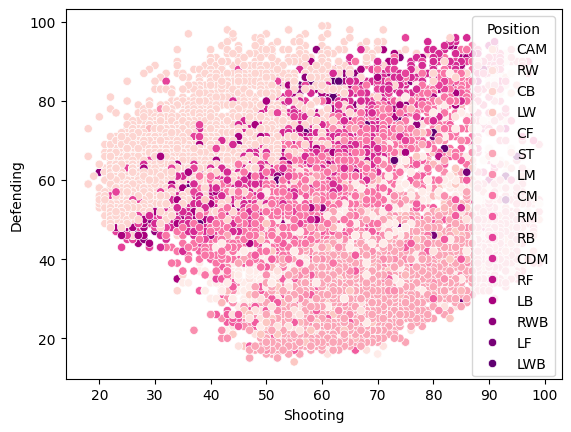

In [ ]:
#השלימו כאן קטע קוד
sns.scatterplot(x='Shooting', y='Defending', hue='Position', data=players_df, palette = 'RdPu')

<div dir= rtl>

צרו מודל KNeighborsClassifier לתוך משתנה knn שפרמטר ה-k הוא 3.

In [ ]:
#השלימו כאן קטע קוד
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

<div dir= rtl>

כעת אמנו את המודל שלנו עם סט האימון (נצטרך גם את החלק של הפיצ'רים  וגם את החלק של הלייבלים)


In [ ]:
#השלימו כאן קטע קוד
knn.fit(features_train, target_train)

/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



KNeighborsClassifier(n_neighbors=3)

<div dir= rtl>

כעת ננסה להעריך כמה מודל ה-KNN שלנו הוא טוב. <br>
זוכרים שבאחד הסעיפים פיצלנו את הנתונים לסט אימון וסט בדיקה? <br>
 הריצו את knn על הנתונים שאותם נרצה לסווג מסט הבדיקה שלנו ונקבל את תוצאות הסיווג במשתנה test_set_prediction.

In [ ]:
#השלימו כאן קטע קוד
test_set_prediction = knn.predict(features_test)
print(test_set_prediction)

['CB' 'CB' 'CB' ... 'CB' 'ST' 'CB']


<div dir="rtl">

חשבו את דיוק המודל, כלומר כמה פעמים המודל חזה את רמת השחקן כראוי מתוך סך השחקנים שהיו בסט המבחן כפי שעשינו במחברת ההדגמה
  </font>

In [ ]:
#השלימו כאן קטע קוד
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(target_test, test_set_prediction)
print(accuracy)

0.9932065217391305


<div dir= rtl>

מעולה. עכשיו שיש לכם את התוצאות וההערכה של הסיווג, נציג תוצאות אלה בצורה אחרת שאנו מכירים היטב- מטריצת בלבול.

איך נעשה זאת? נשתמש בפונקציית confusion_matrix שתבנה לנו את המטריצת בלבול ובפונקציית ConfusionMatrixDisplay שתצייר לנו אותה בגרף יפה באמצעות matplotlib. שני הפונקציות נתונות לנו מספריית sklearn.

העשרה: מוזמנים להציץ [במדריך](https://www.w3schools.com/python/python_ml_confusion_matrix.asp) כדי לקבל הצצה לפונקציות אלו שנלמד עליהן שיעור הבא.

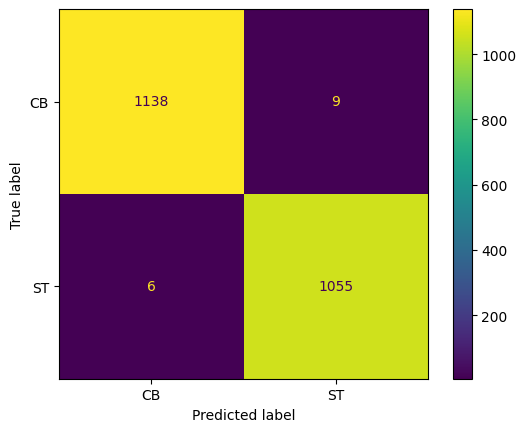

In [ ]:
#@title הריצו את הקוד על מנת לראות את המטריצת בלבול בגרף
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

confusion_mat=confusion_matrix(target_test,test_set_prediction)

ConfusionMatrixDisplay(confusion_mat,display_labels=knn.classes_).plot()
plt.show()

<div dir= rtl>
<b>


לאחר שראינו את מטריצת הבלבול, האם המודל שלנו הוא מודל טוב? איך ניתן לדעת זאת?

--------------------------------------------------------------------------------
<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
</font>
<br>


**תשובה:**

אני חושבת שבמודל הוא טוב ככי האחוז דיוק שלי גבוה (אני חושבת, אבל אני לא מאוד מבינה איך אני אמורה לקרוא את המטריצה הזום
וגם הייתי צריכה עוד פעם לשנות את השמות של המשתנים בפנים אז יככול להיות שזה גם פגע בביצוע של הדפסת מטריצת בלבול נורמאלית
--------------------------------------------------------------------------------

</b></div>

<div dir= rtl>

מזל טוב! הגיע אלינו שחקן חדש מקבוצת הנוער. הבעיה היא שאמנם אנחנו יודעים את הנתונים שלו, אך אין לנו מושג איזה מיקום הכי מתאים לו על המגרש.

הנתונים שלו הם:

* Shooting: 68
* Defending: 61

השתמשו בknn שלנו על מנת לסווג את השחקן למיקום שהכי מתאים לו (CB או ST)

In [ ]:
#השלימו כאן קטע קוד
new_player = pd.DataFrame({'Shooting': [68], 'Defending': [61]})
predicted_position = knn.predict(new_player)

print(predicted_position[0])

ST


<div dir= rtl>

ענו על השאלות הבאות לאחר שבדקתם אותם בקוד ורשמו את הקוד שבאמצעותו בדקתם במקום המתאים למטה.


1)
מה היה קורה לסיווג השחקן החדש אם היינו מגדירים את K להיות שווה ל-1? **תשובה:**

2)
מה היה קורה לסיווג השחקן החדש אם היינו מגדירים את K להיות שווה ל-5700? **תשובה:**

3)
מה היה קורה לסיווג השחקן החדש אם הנתונים שלו היו מתהפכים והיינו מריצים אותו על knn המקורי? **תשובה:**


In [ ]:
#1
#השלימו כאן קטע קוד
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(features_test, target_test)
predicted_position = knn1.predict(new_player)
print(predicted_position[0])

#2
#השלימו כאן קטע קוד
knn2 = KNeighborsClassifier(n_neighbors=5700) #זה לא רץ לי ואני חושב תכי זה אומר שאין מספיק נתונים? אבל אני לא מאוד מבינה
knn2.fit(features_test, target_test)
predicted_position = knn2.predict(new_player)
print(predicted_position[0])

#3
#השלימו כאן קטע קוד


ST


/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



ValueError: Expected n_neighbors <= n_samples,  but n_samples = 2208, n_neighbors = 5700

In [ ]:
new_player2 = pd.DataFrame({'Shooting': [61], 'Defending': [68]})
predicted_position = knn.predict(new_player)
print(predicted_position[0])

ST


<div dir= rtl>

במצגת השיעור למדנו שאפשר להריץ מודל KNN עם יותר משני פיצ'רים.<br>
האם לדעתכם הוספת כל הפיצ'רים השונים במסד הנתונים תשפר את המודל? הסבירו את תשובתכם


<div dir= rtl>

--------------------------------------------------------------------------------
<b>
<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
</font>
<br>


**תשובה:**
לא בהכרח ככי הכל תלוי באיכו הנתונים אבל אם כל הנתונים מלאים ואמינים אז כן
--------------------------------------------------------------------------------

</b></div>

<div dir= rtl>

הוכיחו את תשובתכם, חזרו על הפעולות השונות שביצעתם בשביל לבנות את המודל אך הפעם בחרו את כל הפיצ'רים הכמותיים שיש לכם במסד הנתונים.<br>
הינכם יכולים לכתוב את כל הקוד בתיבה אחת ולהדפיס את דיוק המודל שיצא לכם.



In [ ]:
players_df

,Name,Rating,Position,Country,Speed,Shooting,Passing,Dribbling,Defending,Physicality,Link
0,Mohamed Salah,99,CAM,Egypt,99,99,96,99,54,88,https://wefut.com/player/22/23557/mohamed-salah
1,Ousmane Dembélé,99,RW,France,99,96,94,99,49,79,https://wefut.com/player/22/22456/ousmane-dembele
2,Raphaël Varane,99,CB,France,96,61,80,83,99,98,https://wefut.com/player/22/22450/raphael-varane
3,Cristiano Ronaldo,99,LW,Portugal,99,99,90,97,50,92,https://wefut.com/player/22/22188/cristiano-ro...
4,Lionel Messi,99,CF,Argentina,95,98,99,99,42,78,https://wefut.com/player/22/22165/lionel-messi
...,...,...,...,...,...,...,...,...,...,...,...
20678,Patrick Ferry,47,ST,Northern Ireland,49,48,38,43,18,37,https://wefut.com/player/22/17124/patrick-ferry
20679,Fang Xinfeng,47,CDM,China PR,54,31,43,44,43,52,https://wefut.com/player/22/17123/fang-xinfeng
20680,Wang Shilong,47,CB,China PR,61,23,27,33,52,46,https://wefut.com/player/22/17122/wang-shilong
20681,Darren Collins,47,ST,Republic of Ireland,68,48,43,51,31,35,https://wefut.com/player/22/17121/darren-collins


In [ ]:
#השלימו כאן קטע קוד
X = df[['Shooting', 'Passing', 'Dribbling', 'Defending', 'Physicality']]
y = df[['Position']]

X_train, X_test, y_train, y_test = train_test_split(Features, Target, test_size=0.2, random_state=4)

knn4 = KNeighborsClassifier(n_neighbors=3)
knn4.fit(X_train, y_train)

test_set_prediction4 = knn4.predict(X_test)
accuracyy = accuracy_score(y_test, test_set_prediction4)

print(accuracyy)

/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



0.9925271739130435


<div dir= rtl>

האם כאשר הוספנו עוד פיצ'רים המודל השתפר?


<div dir= rtl>

--------------------------------------------------------------------------------
<b>
<div dir="rtl">
<font color='#Green' size="4">
<b>
ענו כאן
</font>
<br>


**תשובה:**

לא וזה כניראה בגלל מה שחשבתי לפני ככן
--------------------------------------------------------------------------------

</b></div>

<H5 dir=rtl align=center>

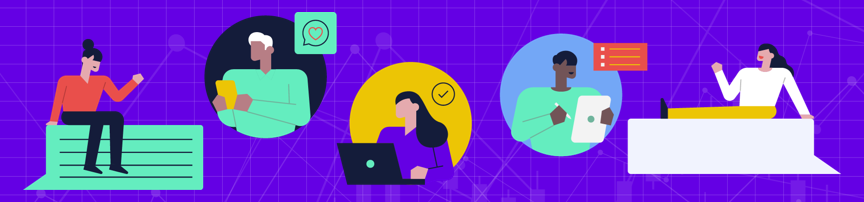

</H5>
